# EDA

What's the conversion rate?
Are the classes imbalanced?
Which features appear important?
Are there missing values?
What distributions do we have?
Which columns are categorical?
Which columns are numerical?

## Dataset Overview

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

In [46]:
import pandas as pd
df = pd.read_csv("../data/marketing_conversion_data.csv")
df.head()

,age,annual_income,country,device_type,traffic_source,campaign_type,pages_visited,session_duration,email_opens,email_clicks,previous_purchases,days_since_last_visit,discount_offered,ad_spend,converted
0,54,97380.0,USA,Desktop,Instagram,Discount,6,207.0,0,0,1,24.0,10,5.35,0
1,29,98272.0,USA,Desktop,Email,Discount,7,480.0,2,1,1,24.0,0,11.57,0
2,59,69856.0,USA,Mobile,Instagram,Newsletter,4,113.0,6,4,0,0.0,5,8.03,0
3,34,28250.0,USA,Mobile,TikTok,Retargeting,6,403.0,2,0,0,126.0,5,6.75,0
4,28,70258.0,USA,Desktop,TikTok,Brand Awareness,5,498.0,2,0,0,5.0,25,8.09,0


In [47]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    25000 non-null  int64  
 1   annual_income          25000 non-null  float64
 2   country                25000 non-null  str    
 3   device_type            25000 non-null  str    
 4   traffic_source         25000 non-null  str    
 5   campaign_type          25000 non-null  str    
 6   pages_visited          25000 non-null  int64  
 7   session_duration       25000 non-null  float64
 8   email_opens            25000 non-null  int64  
 9   email_clicks           25000 non-null  int64  
 10  previous_purchases     25000 non-null  int64  
 11  days_since_last_visit  25000 non-null  float64
 12  discount_offered       25000 non-null  int64  
 13  ad_spend               25000 non-null  float64
 14  converted              25000 non-null  int64  
dtypes: float64(4)

In [48]:
df.describe()

,age,annual_income,pages_visited,session_duration,email_opens,email_clicks,previous_purchases,days_since_last_visit,discount_offered,ad_spend,converted
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,43.287480,72116.811440,5.602960,322.177480,2.285240,0.775600,0.673760,20.518040,9.873600,13.154812,0.389360
std,14.968993,21614.795306,2.692673,205.018985,1.750954,1.044992,0.807709,24.629649,8.290764,8.847894,0.487615
min,18.000000,25000.000000,1.000000,10.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,0.500000,0.000000
25%,30.000000,57164.250000,4.000000,170.000000,1.000000,0.000000,0.000000,2.000000,0.000000,6.650000,0.000000
50%,43.000000,72090.000000,5.000000,304.000000,2.000000,0.000000,0.000000,12.000000,10.000000,11.240000,0.000000
75%,56.000000,86750.000000,7.000000,452.000000,3.000000,1.000000,1.000000,30.000000,15.000000,17.510000,1.000000
max,69.000000,171274.000000,18.000000,1458.000000,13.000000,10.000000,6.000000,180.000000,25.000000,73.620000,1.000000


In [49]:
df.shape

(25000, 15)

## Target distribution

In [50]:

df["converted"].value_counts(normalize=True)

converted
0    0.61064
1    0.38936
Name: proportion, dtype: float64

Above is a pretty typical conversion distribution for marketing campaigns.  
39% of leads convert  
61% do not  
  
The target variable exhibits a slight class imbalance. While this imbalance is not severe, it should be considered during model evaluation. Metrics such as F1-score, precision, recall, and ROC-AUC may provide a more informative assessment than accuracy alone.

## Missing values

In [51]:
df.isna().sum()

age                      0
annual_income            0
country                  0
device_type              0
traffic_source           0
campaign_type            0
pages_visited            0
session_duration         0
email_opens              0
email_clicks             0
previous_purchases       0
days_since_last_visit    0
discount_offered         0
ad_spend                 0
converted                0
dtype: int64

## Numerical Distributions
Histograms for session_duration, pages_visited, annual_income, and ad_spend

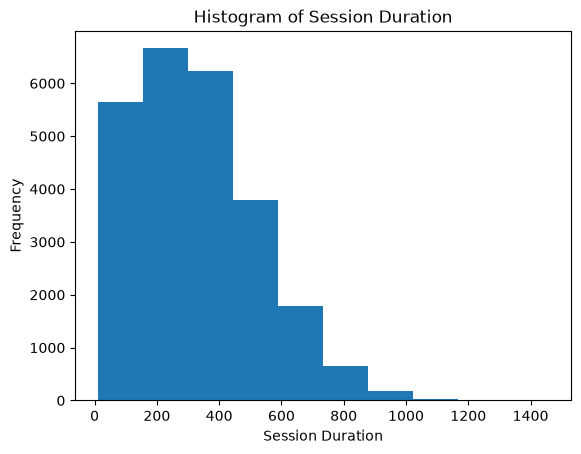

In [52]:
plt.hist(df["session_duration"])
plt.xlabel("Session Duration")
plt.ylabel("Frequency")
plt.title("Histogram of Session Duration")
plt.show()

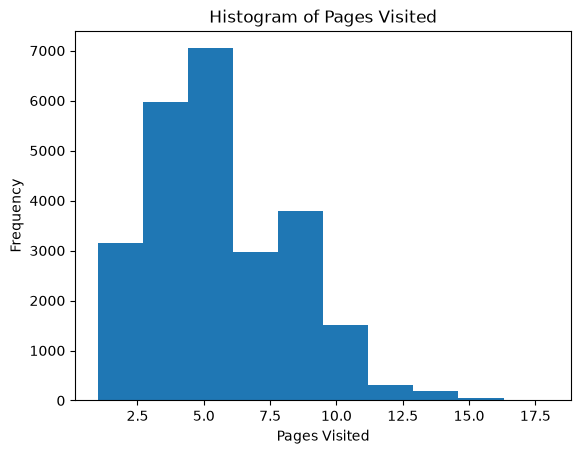

In [53]:
plt.hist(df["pages_visited"])
plt.xlabel("Pages Visited")
plt.ylabel("Frequency")
plt.title("Histogram of Pages Visited")
plt.show()

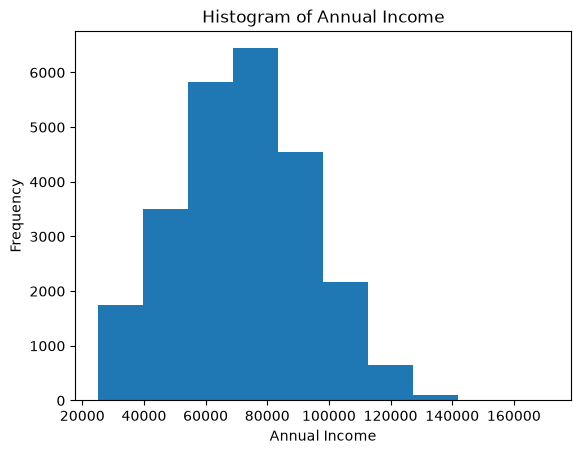

In [54]:
plt.hist(df["annual_income"])
plt.xlabel("Annual Income")
plt.ylabel("Frequency")
plt.title("Histogram of Annual Income")
plt.show()

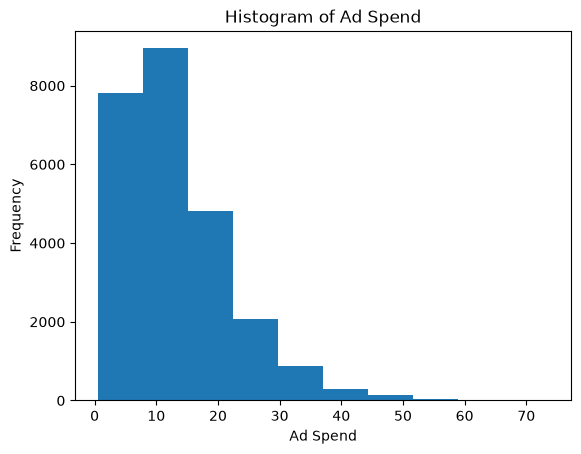

In [55]:
plt.hist(df["ad_spend"])
plt.xlabel("Ad Spend")
plt.ylabel("Frequency")
plt.title("Histogram of Ad Spend")
plt.show()

## Categorical Distributions
Bar charts for traffic_source, campaign_type, device_type, country

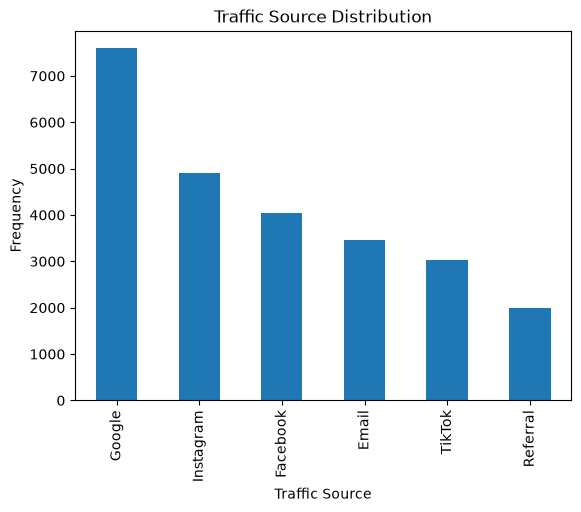

In [56]:
df["traffic_source"].value_counts().plot(kind="bar")
plt.xlabel("Traffic Source")
plt.ylabel("Frequency")
plt.title("Traffic Source Distribution")
plt.show()

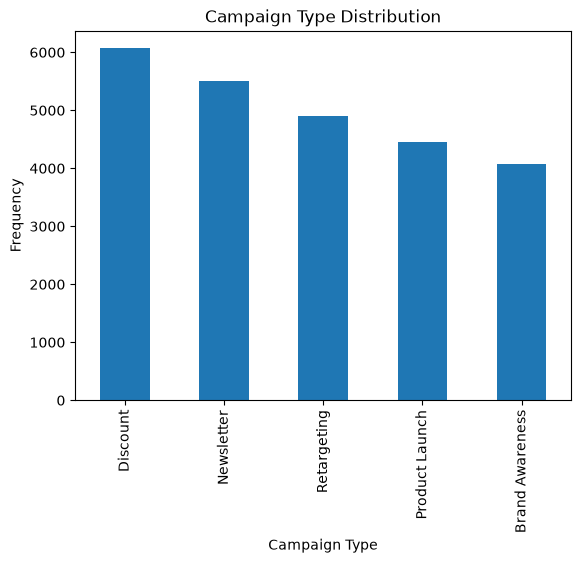

In [57]:
df["campaign_type"].value_counts().plot(kind="bar")
plt.xlabel("Campaign Type")
plt.ylabel("Frequency")
plt.title("Campaign Type Distribution")
plt.show()

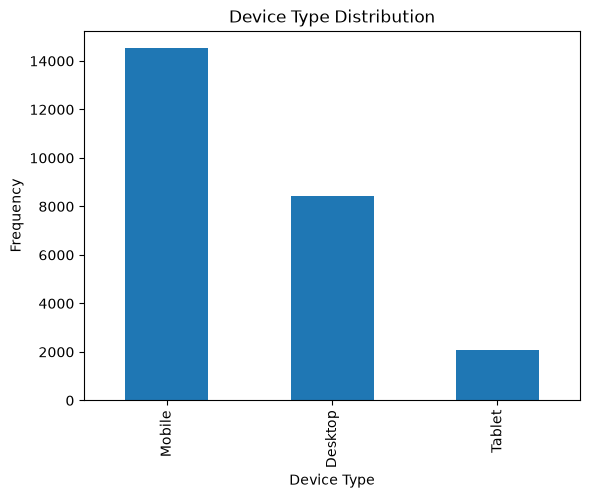

In [58]:
df["device_type"].value_counts().plot(kind="bar")
plt.xlabel("Device Type")
plt.ylabel("Frequency")
plt.title("Device Type Distribution")
plt.show()

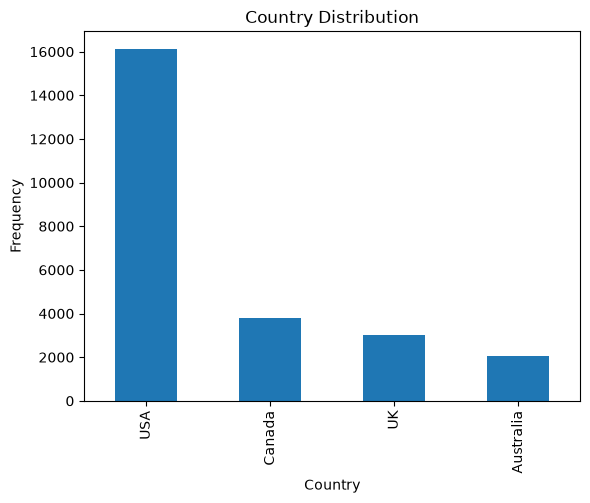

In [59]:
df["country"].value_counts().plot(kind="bar")
plt.xlabel("Country")
plt.ylabel("Frequency")
plt.title("Country Distribution")
plt.show()

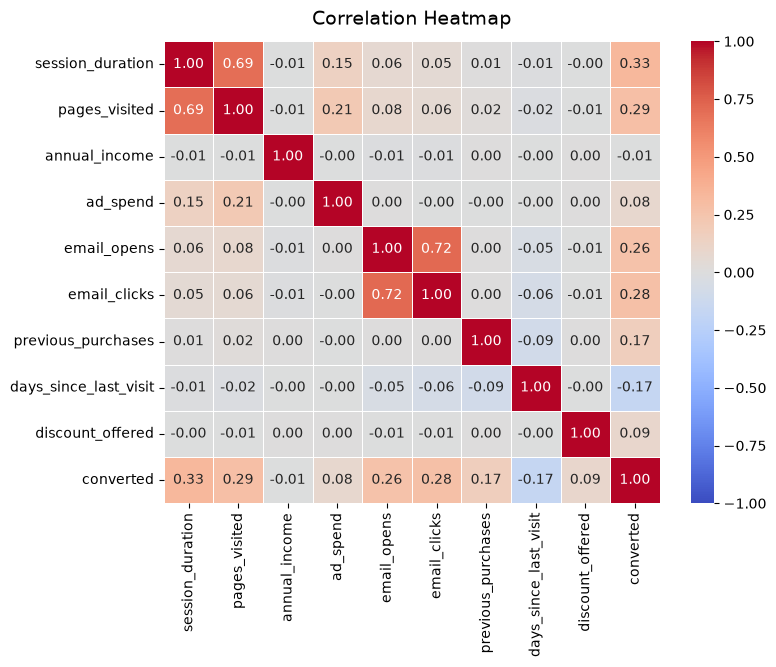

In [60]:
# 2. Calculate the pairwise correlation matrix
num_df = df[
    [
        "session_duration",
        "pages_visited",
        "annual_income",
        "ad_spend",
        "email_opens",
        "email_clicks",
        "previous_purchases",
        "days_since_last_visit",
        "discount_offered",
        "converted"
    ]
]

corr_matrix = num_df.corr(numeric_only=True)

plt.figure(figsize=(8, 6))

# 4. Draw the heatmap with customizations
sns.heatmap(
    corr_matrix, 
    annot=True,          # Display the correlation coefficients in each cell
    cmap='coolwarm',     # Use a divergent color map (blue for negative, red for positive)
    vmin=-1, vmax=1,     # Anchor the colorbar limits between -1 and 1
    linewidths=0.5,      # Add subtle lines between cells
    fmt='.2f'            # Format numbers to 2 decimal places
)

# 5. Final touches and rendering
plt.title('Correlation Heatmap', fontsize=14, pad=12)
plt.show()

Above we see correlation between features.  
Notable correlations:  
pages_visited + session_duration  
email_opens + email_clicks  

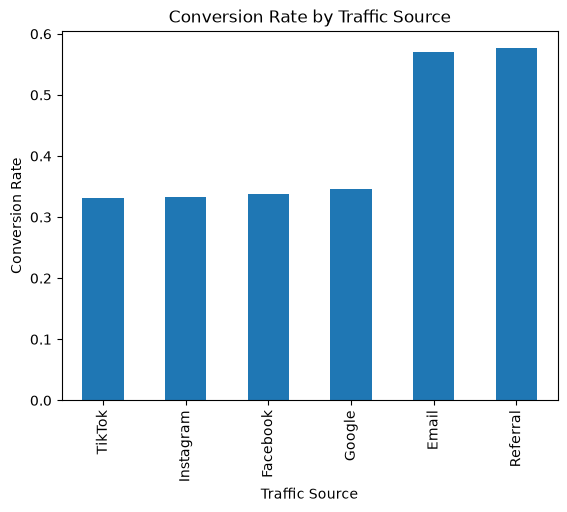

In [61]:
df.groupby("traffic_source")["converted"].mean().sort_values().plot.bar()
plt.xlabel("Traffic Source")
plt.ylabel("Conversion Rate")
plt.title("Conversion Rate by Traffic Source")
plt.show()

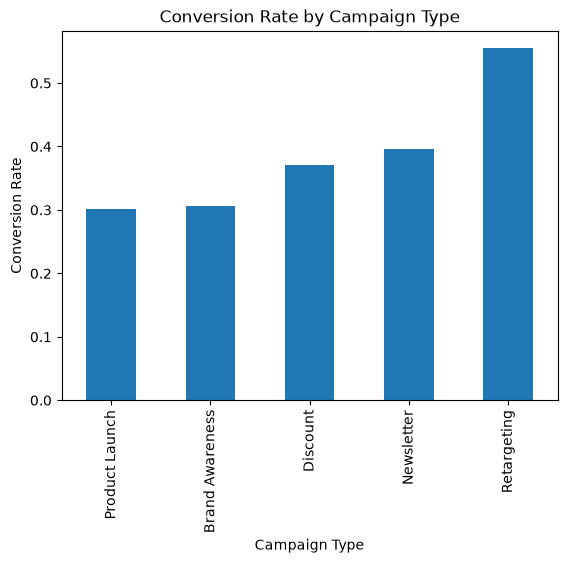

In [62]:
df.groupby("campaign_type")["converted"].mean().sort_values().plot.bar()
plt.xlabel("Campaign Type")
plt.ylabel("Conversion Rate")
plt.title("Conversion Rate by Campaign Type")
plt.show()

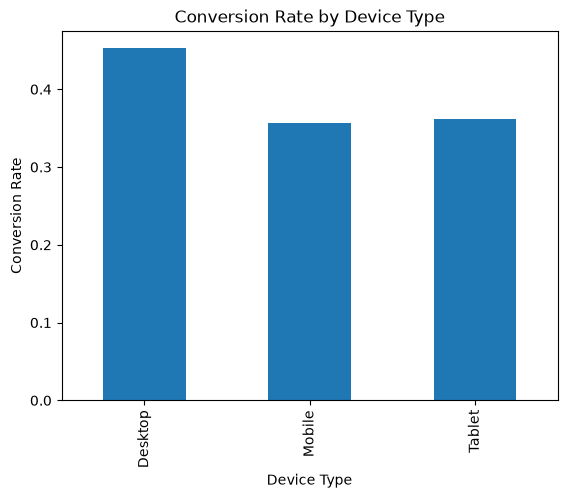

In [63]:
df.groupby("device_type")["converted"].mean().plot.bar()
plt.xlabel("Device Type")
plt.ylabel("Conversion Rate")
plt.title("Conversion Rate by Device Type")
plt.show()

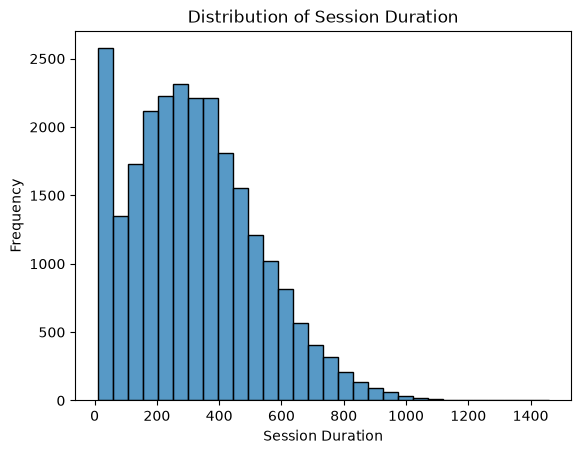

In [64]:
sns.histplot(df["session_duration"], bins=30)
plt.xlabel("Session Duration")
plt.ylabel("Frequency")
plt.title("Distribution of Session Duration")
plt.show()

<Axes: xlabel='converted', ylabel='session_duration'>

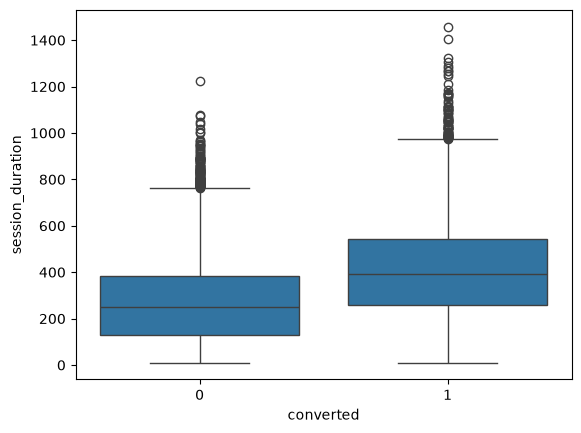

In [65]:
sns.boxplot(
    x="converted",
    y="session_duration",
    data=df
)

## Plan for train.py (feature engineering)

To encode our features, I'll be creating a pipeline and using ColumnTransformer instead of using pd.get_dummies() so that if our API receives a value it wasn't trained on, it doesn't crash.  

Raw Data

↓

Pipeline  
  
├── ColumnTransformer  
  │  
├── OneHotEncoder  
  │  
└── RandomForestClassifier  

Then the API can feed the model raw data.  
_______________________________________________________
  
First let's identify our columns:  
  
**Numerical**:  
age  
annual_income  
pages_visited  
session_duration  
email_opens  
email_clicks  
previous_purchases  
days_since_last_visit  
discount_offered  
ad_spend  
  
**Categorical**:  
country  
device_type  
traffic_source  
campaign_type  
  
**Target**:  
converted  
___________________________________________________
  
Then we'll build this architecture:  
  
numeric_transformer

↓

categorical_transformer

↓

ColumnTransformer

↓

RandomForestClassifier

↓

Pipeline